# 卸料任务时间与能耗预测

本 Notebook 使用同一份数据、同一次训练集/测试集划分比较以下模型：

1. **Baseline 1：里程比例模型**
2. **Baseline 2：普通线性回归**
3. **默认参数 XGBoost**
4. **网格搜索后的 XGBoost**

网格搜索只在训练集上进行，测试集不参与参数选择。任务时间模型和能耗模型分别搜索最优参数。

发车时间使用 `sin + cos` 周期编码，因此 23 点和 0 点在特征空间中相近。

## 1. 导入依赖

首次运行前请确保已安装：

```bash
pip install pandas numpy matplotlib scikit-learn xgboost joblib
```

In [66]:
import json
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import (
    GridSearchCV,
    KFold,
    cross_validate,
    train_test_split,
)
from xgboost import XGBRegressor


# 绘图显示设置
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["font.sans-serif"] = [
    "Microsoft YaHei",
    "SimHei",
    "Arial Unicode MS",
    "DejaVu Sans",
]

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)

print("依赖导入完成。")

依赖导入完成。


## 2. 设置数据路径和模型参数

只需要重点修改 `DATA_DIR`。

程序会递归读取该目录及其子目录中的全部 JSON 特征文件。

In [67]:
# 特征 JSON 所在目录（从 src/ 目录向上一级）
DATA_DIR = Path(r"../data/FeatureData")

# 结果保存目录
OUTPUT_DIR = Path(r"../target/ModelResults")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


FEATURE_COLS = [
    "departure_hour_sin",
    "departure_hour_cos",
    "total_distance_odometer_m",
    "total_altitude_change_m",
    "pitch_mean",
    "pitch_std",
    "speed_mean",
    "speed_std",
]

TIME_TARGET = "task_duration_s"
ENERGY_TARGET = "total_energy_soc_delta_pct"

TEST_SIZE = 0.2
RANDOM_STATE = 42

print("数据目录：", DATA_DIR)
print("结果目录：", OUTPUT_DIR)

# XGBoost 网格搜索设置
GRID_SEARCH_CV_FOLDS = 5

print(f"网格搜索交叉验证折数：{GRID_SEARCH_CV_FOLDS}")

数据目录： ..\data\FeatureData
结果目录： ..\target\ModelResults
网格搜索交叉验证折数：5


## 3. 读取并合并全部 JSON

兼容两种 JSON 结构：

- `{"tasks": [...]}`
- 直接使用任务列表 `[...]`

缺少必要字段的文件会被跳过。

In [68]:
def load_dataset(data_dir):
    json_files = sorted(data_dir.rglob("*.json"))

    if len(json_files) == 0:
        raise FileNotFoundError(f"没有找到 JSON 文件：{data_dir}")

    required_cols = FEATURE_COLS + [TIME_TARGET, ENERGY_TARGET]
    all_data = []
    skipped_files = []

    for json_file in json_files:
        try:
            with json_file.open("r", encoding="utf-8") as f:
                data = json.load(f)

            if isinstance(data, dict) and isinstance(data.get("tasks"), list):
                tasks = data["tasks"]
            elif isinstance(data, list):
                tasks = data
            else:
                skipped_files.append((json_file.name, "没有任务列表"))
                continue

            file_df = pd.DataFrame(tasks)

            missing_cols = [
                col for col in required_cols
                if col not in file_df.columns
            ]

            if len(missing_cols) > 0:
                skipped_files.append(
                    (json_file.name, f"缺少字段：{missing_cols}")
                )
                continue

            if "task_id" not in file_df.columns:
                file_df["task_id"] = pd.NA

            if "task_index" not in file_df.columns:
                file_df["task_index"] = pd.NA

            file_df["source_file"] = str(
                json_file.relative_to(data_dir)
            )

            keep_cols = (
                required_cols
                + ["task_id", "task_index", "source_file"]
            )

            all_data.append(file_df[keep_cols].copy())

        except Exception as error:
            skipped_files.append((json_file.name, str(error)))

    if len(all_data) == 0:
        raise ValueError("没有成功读取任何可用数据。")

    df = pd.concat(all_data, ignore_index=True)

    for col in required_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    original_count = len(df)

    df = df.dropna(subset=required_cols)
    df = df[
        (df["total_distance_odometer_m"] >= 0)
        & (df[TIME_TARGET] > 0)
    ].reset_index(drop=True)

    print(f"发现 JSON 文件数：{len(json_files)}")
    print(f"成功读取文件数：{len(all_data)}")
    print(f"原始任务数：{original_count}")
    print(f"有效任务数：{len(df)}")
    print(f"删除无效任务数：{original_count - len(df)}")

    if len(skipped_files) > 0:
        print(f"\n跳过文件数：{len(skipped_files)}")
        for file_name, reason in skipped_files:
            print(f"- {file_name}: {reason}")

    return df


df = load_dataset(DATA_DIR)

发现 JSON 文件数：10
成功读取文件数：10
原始任务数：1094
有效任务数：1094
删除无效任务数：0


## 4. 查看数据

先检查样本数量、字段内容和主要统计量。

In [69]:
print("数据形状：", df.shape)
print("数据文件数：", df["source_file"].nunique())

display(df.head())

summary_cols = FEATURE_COLS + [TIME_TARGET, ENERGY_TARGET]
display(df[summary_cols].describe().T.round(4))

数据形状： (1094, 13)
数据文件数： 10


,departure_hour_sin,departure_hour_cos,total_distance_odometer_m,total_altitude_change_m,pitch_mean,pitch_std,speed_mean,speed_std,task_duration_s,total_energy_soc_delta_pct,task_id,task_index,source_file
0,-0.456174,-0.889890,3500.0,144.5831,-1.928053,2.509720,3.297326,1.592501,1078.880390,14.8,8061955916906753,1,TLE00860CR1450020卸料任务_特征和标签.json
1,-0.914676,0.404187,4500.0,132.5124,-1.727225,2.499827,4.281888,2.113034,1078.446503,13.6,8062296833835265,2,TLE00860CR1450020卸料任务_特征和标签.json
2,-0.695656,0.718375,4125.0,172.0542,-2.281552,2.496671,3.504632,1.329558,1218.586187,16.0,8062383657042177,3,TLE00860CR1450020卸料任务_特征和标签.json
3,-0.521993,0.852950,3500.0,144.3345,-1.711009,2.469314,3.076494,1.659597,1193.786143,12.8,8062433255342337,4,TLE00860CR1450020卸料任务_特征和标签.json
4,-0.110991,0.993821,5125.0,161.8966,-2.033794,2.352843,4.059008,2.049870,1303.056854,16.0,8062531927441665,5,TLE00860CR1450020卸料任务_特征和标签.json


,count,mean,std,min,25%,50%,75%,max
departure_hour_sin,1094.0,0.0183,0.6972,-1.0000,-0.6486,0.0059,0.7212,1.0000
departure_hour_cos,1094.0,0.1063,0.7093,-1.0000,-0.6088,0.2182,0.8029,1.0000
total_distance_odometer_m,1094.0,3952.8108,736.7995,2500.0000,3375.0000,4000.0000,4500.0000,6125.0000
total_altitude_change_m,1094.0,151.9531,17.7075,101.2538,137.2862,152.5699,167.8093,174.6746
pitch_mean,1094.0,-2.0539,0.7905,-3.8464,-2.8258,-1.9078,-1.6056,0.4365
pitch_std,1094.0,2.5370,0.1385,2.2127,2.4417,2.5286,2.6173,3.6636
speed_mean,1094.0,3.4581,0.3162,1.9205,3.2920,3.4157,3.5660,4.2819
speed_std,1094.0,1.6222,0.3144,1.1544,1.3747,1.5066,1.8495,2.6924
task_duration_s,1094.0,1198.9027,191.7145,784.8793,1062.8754,1195.5790,1338.2242,2227.9115
total_energy_soc_delta_pct,1094.0,15.0980,2.1246,10.4000,13.6000,15.2000,16.8000,21.2000


## 5. 统一划分训练集和测试集

三个模型使用完全相同的训练集和测试集。

这样可以直接比较 MAE、RMSE 和 R²。

In [70]:
train_index, test_index = train_test_split(
    df.index,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
)

train_df = df.loc[train_index].reset_index(drop=True)
test_df = df.loc[test_index].reset_index(drop=True)

X_train = train_df[FEATURE_COLS]
X_test = test_df[FEATURE_COLS]

y_time_train = train_df[TIME_TARGET]
y_time_test = test_df[TIME_TARGET]

y_energy_train = train_df[ENERGY_TARGET]
y_energy_test = test_df[ENERGY_TARGET]

print(f"训练集样本数：{len(train_df)}")
print(f"测试集样本数：{len(test_df)}")

训练集样本数：875
测试集样本数：219


## 6. 指标计算与绘图函数

- **MAE**：平均绝对误差，越小越好；
- **RMSE**：均方根误差，越小越好；
- **R²**：决定系数，越接近 1 越好。

In [71]:
def get_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": mean_squared_error(y_true, y_pred) ** 0.5,
        "R2": r2_score(y_true, y_pred),
    }


def plot_actual_vs_predicted(y_true, y_pred, title, unit):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    min_value = min(y_true.min(), y_pred.min())
    max_value = max(y_true.max(), y_pred.max())

    plt.figure(figsize=(7, 6))
    plt.scatter(y_true, y_pred, s=45, alpha=0.75)
    plt.plot(
        [min_value, max_value],
        [min_value, max_value],
        linestyle="--",
        linewidth=1.8,
        label="理想预测线",
    )
    plt.xlabel(f"真实值（{unit}）")
    plt.ylabel(f"预测值（{unit}）")
    plt.title(title, fontsize=14, pad=12)
    plt.grid(alpha=0.25)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_residuals(y_true, y_pred, title, unit):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    residuals = y_pred - y_true

    plt.figure(figsize=(7, 5))
    plt.scatter(y_pred, residuals, s=45, alpha=0.75)
    plt.axhline(0, linestyle="--", linewidth=1.8)
    plt.xlabel(f"预测值（{unit}）")
    plt.ylabel(f"残差（{unit}）")
    plt.title(title, fontsize=14, pad=12)
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

# Baseline 1：任务时间和能耗与里程成正比

分别建立两个最简单的比例模型：

\[
\hat{t}=k_t d
\]

\[
\hat{e}=k_e d
\]

其中：

- \(d\)：任务总里程；
- \(k_t\)：时间比例系数；
- \(k_e\)：能耗比例系数；
- \(\hat{t}\)：预测任务时间；
- \(\hat{e}\)：预测行程能耗。

两个系数都只使用训练集计算。

In [72]:
# 只使用训练集计算时间和能耗两个比例系数
distance_train = train_df["total_distance_odometer_m"].to_numpy()

time_train = y_time_train.to_numpy()
energy_train = y_energy_train.to_numpy()

baseline1_time_k = (
    np.sum(distance_train * time_train)
    / np.sum(distance_train ** 2)
)

baseline1_energy_k = (
    np.sum(distance_train * energy_train)
    / np.sum(distance_train ** 2)
)

print(f"时间比例系数：{baseline1_time_k:.8f} 秒/米")
print(f"每公里预测时间：{baseline1_time_k * 1000:.4f} 秒/公里")

if baseline1_time_k > 0:
    constant_speed = 3.6 / baseline1_time_k
    print(f"对应的等效恒定速度：{constant_speed:.4f} km/h")

print()
print(
    f"能耗比例系数："
    f"{baseline1_energy_k:.10f} SOC 百分点/米"
)
print(
    f"每公里预测能耗："
    f"{baseline1_energy_k * 1000:.6f} SOC 百分点/公里"
)

时间比例系数：0.30073917 秒/米
每公里预测时间：300.7392 秒/公里
对应的等效恒定速度：11.9705 km/h

能耗比例系数：0.0037780594 SOC 百分点/米
每公里预测能耗：3.778059 SOC 百分点/公里


### 保存并重新读取比例系数

实际预测时不需要重新训练，只需读取保存的比例系数。

In [73]:
baseline1_model_path = (
    OUTPUT_DIR
    / "baseline1_distance_time_energy_model.json"
)

baseline1_model_data = {
    "model_name": "distance_proportional_time_and_energy_baseline",
    "distance_feature": "total_distance_odometer_m",
    "time": {
        "formula": (
            "predicted_task_duration_s = "
            "time_coefficient_s_per_m * "
            "total_distance_odometer_m"
        ),
        "time_coefficient_s_per_m": float(baseline1_time_k),
        "time_coefficient_s_per_km": float(
            baseline1_time_k * 1000
        ),
    },
    "energy": {
        "formula": (
            "predicted_energy_soc_pct = "
            "energy_coefficient_soc_pct_per_m * "
            "total_distance_odometer_m"
        ),
        "energy_coefficient_soc_pct_per_m": float(
            baseline1_energy_k
        ),
        "energy_coefficient_soc_pct_per_km": float(
            baseline1_energy_k * 1000
        ),
    },
    "train_sample_count": len(train_df),
}

with baseline1_model_path.open("w", encoding="utf-8") as f:
    json.dump(
        baseline1_model_data,
        f,
        ensure_ascii=False,
        indent=2,
    )

# 模拟部署：重新读取两个比例系数
with baseline1_model_path.open("r", encoding="utf-8") as f:
    loaded_baseline1_model = json.load(f)

loaded_time_k = (
    loaded_baseline1_model["time"][
        "time_coefficient_s_per_m"
    ]
)

loaded_energy_k = (
    loaded_baseline1_model["energy"][
        "energy_coefficient_soc_pct_per_m"
    ]
)

baseline1_time_pred = (
    loaded_time_k
    * test_df["total_distance_odometer_m"].to_numpy()
)

baseline1_energy_pred = (
    loaded_energy_k
    * test_df["total_distance_odometer_m"].to_numpy()
)

baseline1_time_metrics = get_metrics(
    y_time_test,
    baseline1_time_pred,
)

baseline1_energy_metrics = get_metrics(
    y_energy_test,
    baseline1_energy_pred,
)

print("模型已保存到：", baseline1_model_path)

print("\n任务时间测试集指标：")
display(pd.DataFrame(
    [baseline1_time_metrics],
    index=["里程比例 Baseline"],
).round(4))

print("行程能耗测试集指标：")
display(pd.DataFrame(
    [baseline1_energy_metrics],
    index=["里程比例 Baseline"],
).round(4))

模型已保存到： ..\target\ModelResults\baseline1_distance_time_energy_model.json

任务时间测试集指标：


,MAE,RMSE,R2
里程比例 Baseline,103.2798,139.1167,0.4747


行程能耗测试集指标：


,MAE,RMSE,R2
里程比例 Baseline,1.3469,1.7132,0.3759


In [74]:
baseline1_preview = test_df[
    [
        "task_id",
        "source_file",
        "total_distance_odometer_m",
        TIME_TARGET,
        ENERGY_TARGET,
    ]
].copy()

baseline1_preview["pred_task_duration_s"] = (
    baseline1_time_pred
)
baseline1_preview["time_residual_s"] = (
    baseline1_preview["pred_task_duration_s"]
    - baseline1_preview[TIME_TARGET]
)

baseline1_preview["pred_energy_soc_pct"] = (
    baseline1_energy_pred
)
baseline1_preview["energy_residual_soc_pct"] = (
    baseline1_preview["pred_energy_soc_pct"]
    - baseline1_preview[ENERGY_TARGET]
)

display(baseline1_preview.head(10).round(4))

,task_id,source_file,total_distance_odometer_m,task_duration_s,total_energy_soc_delta_pct,pred_task_duration_s,time_residual_s,pred_energy_soc_pct,energy_residual_soc_pct
0,8064241511481601,TLE00860VR1450018卸料任务_特征和标签.json,3500.0,1019.1463,13.2,1052.5871,33.4408,13.2232,0.0232
1,8065135005860097,TLE00860ER1450011卸料任务_特征和标签.json,4875.0,1278.7740,16.8,1466.1034,187.3294,18.4180,1.6180
2,8069905531109633,TLE00860CR1450020卸料任务_特征和标签.json,4250.0,1108.9244,14.4,1278.1415,169.2170,16.0568,1.6568
3,8066679182082305,TLE00900JR1450046卸料任务_特征和标签.json,2625.0,820.8870,11.6,789.4403,-31.4466,9.9174,-1.6826
4,8067402709188865,TLE00900AR1450052卸料任务_特征和标签.json,4125.0,1323.0825,16.0,1240.5491,-82.5335,15.5845,-0.4155
5,8064903191462145,TLE00900VR1450048卸料任务_特征和标签.json,4500.0,1364.6498,17.6,1353.3262,-11.3236,17.0013,-0.5987
6,8067366011945217,TLE00860HR1450010卸料任务_特征和标签.json,3000.0,898.3948,11.2,902.2175,3.8227,11.3342,0.1342
7,8061142448472321,TLE00860VR1450018卸料任务_特征和标签.json,4125.0,1221.8573,17.2,1240.5491,18.6917,15.5845,-1.6155
8,8069981954031873,TLE00900VR1450048卸料任务_特征和标签.json,4125.0,1149.1676,15.2,1240.5491,91.3814,15.5845,0.3845
9,8065218275868929,TLE00900AR1450052卸料任务_特征和标签.json,4125.0,1365.7869,16.8,1240.5491,-125.2378,15.5845,-1.2155


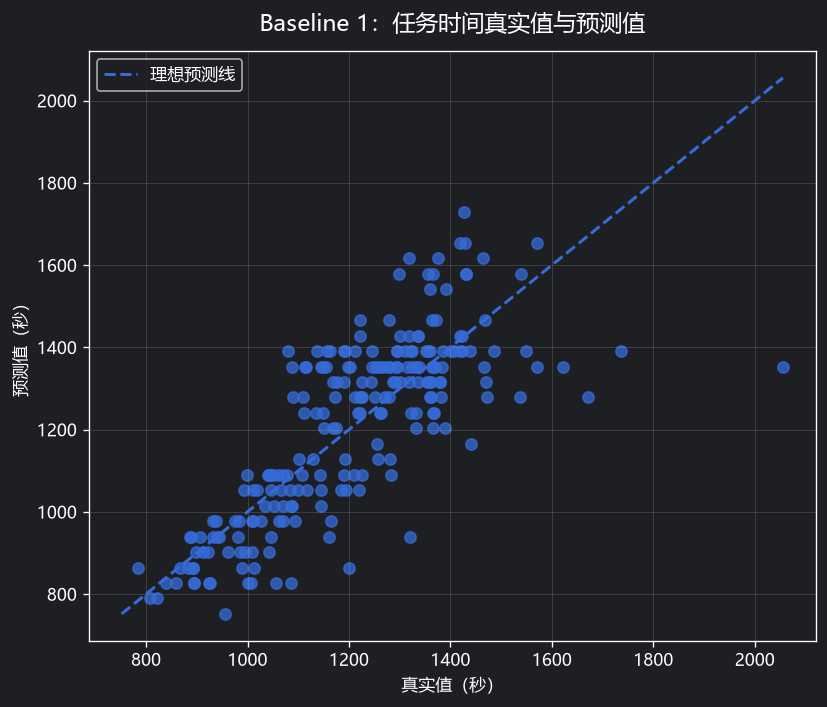

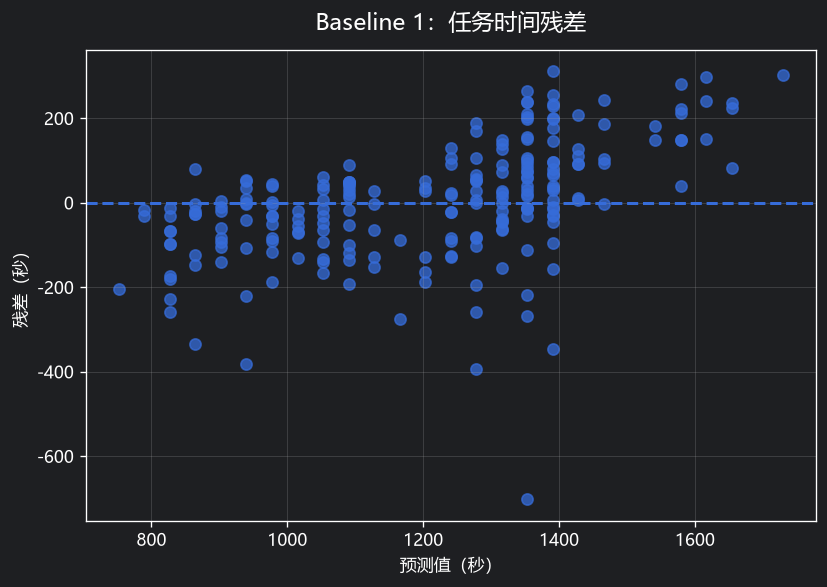

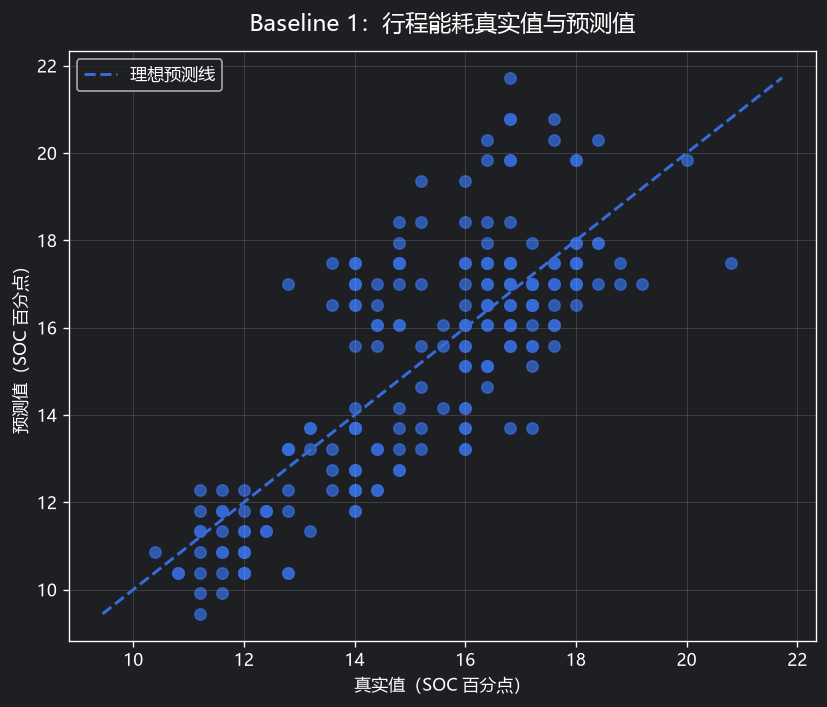

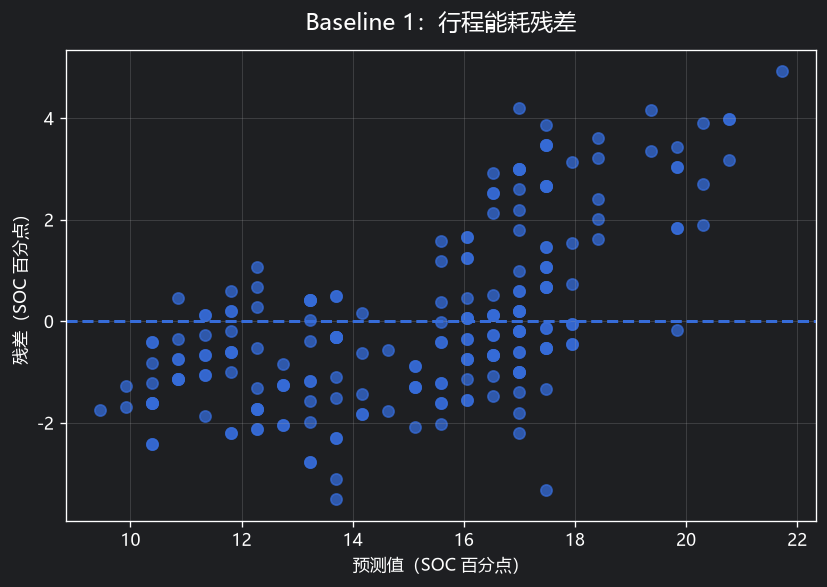

In [75]:
plot_actual_vs_predicted(
    y_time_test,
    baseline1_time_pred,
    "Baseline 1：任务时间真实值与预测值",
    "秒",
)

plot_residuals(
    y_time_test,
    baseline1_time_pred,
    "Baseline 1：任务时间残差",
    "秒",
)

plot_actual_vs_predicted(
    y_energy_test,
    baseline1_energy_pred,
    "Baseline 1：行程能耗真实值与预测值",
    "SOC 百分点",
)

plot_residuals(
    y_energy_test,
    baseline1_energy_pred,
    "Baseline 1：行程能耗残差",
    "SOC 百分点",
)

# Baseline 2：普通线性回归

使用全部任务级特征，分别建立：

- 任务时间线性回归；
- 能耗线性回归。

线性回归形式为：

\[
\hat{y}=b+w_1x_1+w_2x_2+\cdots+w_px_p
\]

In [76]:
# 任务时间线性回归
linear_time_model = LinearRegression()
linear_time_model.fit(X_train, y_time_train)
linear_time_pred = linear_time_model.predict(X_test)

linear_time_metrics = get_metrics(
    y_time_test,
    linear_time_pred,
)

# 能耗线性回归
linear_energy_model = LinearRegression()
linear_energy_model.fit(X_train, y_energy_train)
linear_energy_pred = linear_energy_model.predict(X_test)

linear_energy_metrics = get_metrics(
    y_energy_test,
    linear_energy_pred,
)

print("任务时间线性回归：")
display(pd.DataFrame(
    [linear_time_metrics],
    index=["线性回归"],
).round(4))

print("能耗线性回归：")
display(pd.DataFrame(
    [linear_energy_metrics],
    index=["线性回归"],
).round(4))

任务时间线性回归：


,MAE,RMSE,R2
线性回归,31.2902,38.9808,0.9588


能耗线性回归：


,MAE,RMSE,R2
线性回归,0.6546,0.8172,0.858


### 查看线性回归系数

注意：不同特征的量纲不同，因此原始系数大小不能直接等同于特征重要性。

In [77]:
linear_time_coef = pd.DataFrame({
    "feature": FEATURE_COLS,
    "coefficient": linear_time_model.coef_,
})

linear_energy_coef = pd.DataFrame({
    "feature": FEATURE_COLS,
    "coefficient": linear_energy_model.coef_,
})

print(f"任务时间模型截距：{linear_time_model.intercept_:.6f}")
display(
    linear_time_coef
    .sort_values("coefficient", key=abs, ascending=False)
    .round(6)
)

print(f"能耗模型截距：{linear_energy_model.intercept_:.6f}")
display(
    linear_energy_coef
    .sort_values("coefficient", key=abs, ascending=False)
    .round(6)
)

任务时间模型截距：815.838786


,feature,coefficient
6,speed_mean,-372.187957
7,speed_std,135.678074
5,pitch_std,70.435712
0,departure_hour_sin,-8.760070
3,total_altitude_change_m,2.390562
1,departure_hour_cos,1.203489
4,pitch_mean,-0.369026
2,total_distance_odometer_m,0.229564


能耗模型截距：1.006161


,feature,coefficient
6,speed_mean,-0.981838
5,pitch_std,0.511463
0,departure_hour_sin,-0.116581
4,pitch_mean,-0.103483
1,departure_hour_cos,0.077805
3,total_altitude_change_m,0.063858
7,speed_std,0.024412
2,total_distance_odometer_m,0.001580


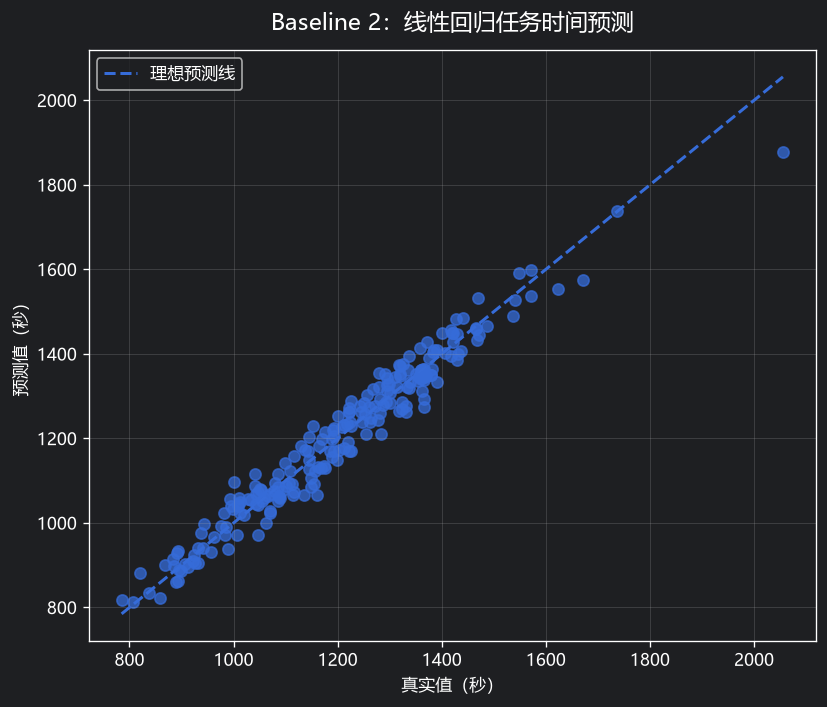

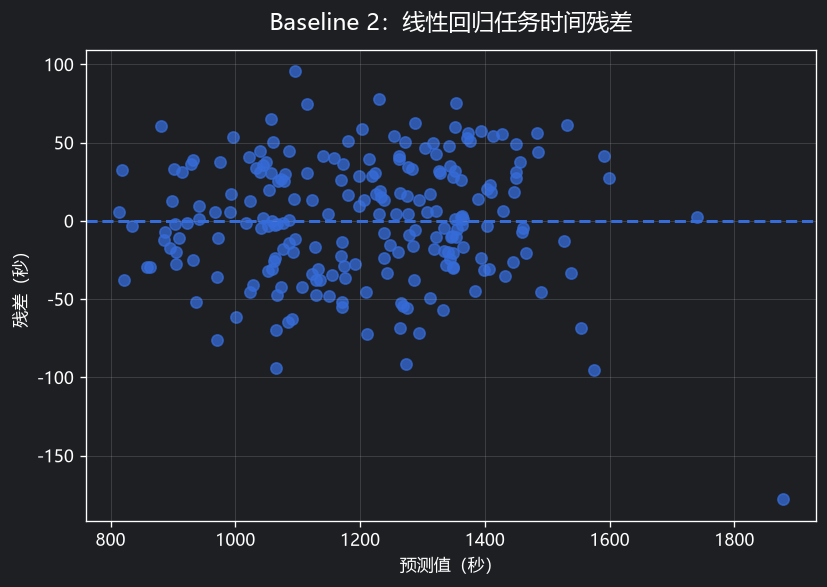

In [78]:
plot_actual_vs_predicted(
    y_time_test,
    linear_time_pred,
    "Baseline 2：线性回归任务时间预测",
    "秒",
)

plot_residuals(
    y_time_test,
    linear_time_pred,
    "Baseline 2：线性回归任务时间残差",
    "秒",
)

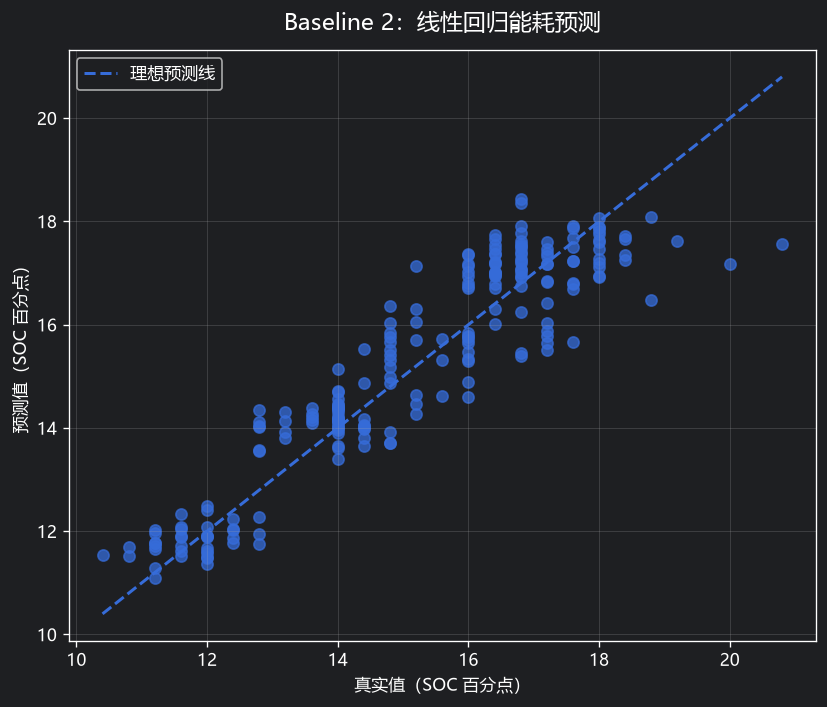

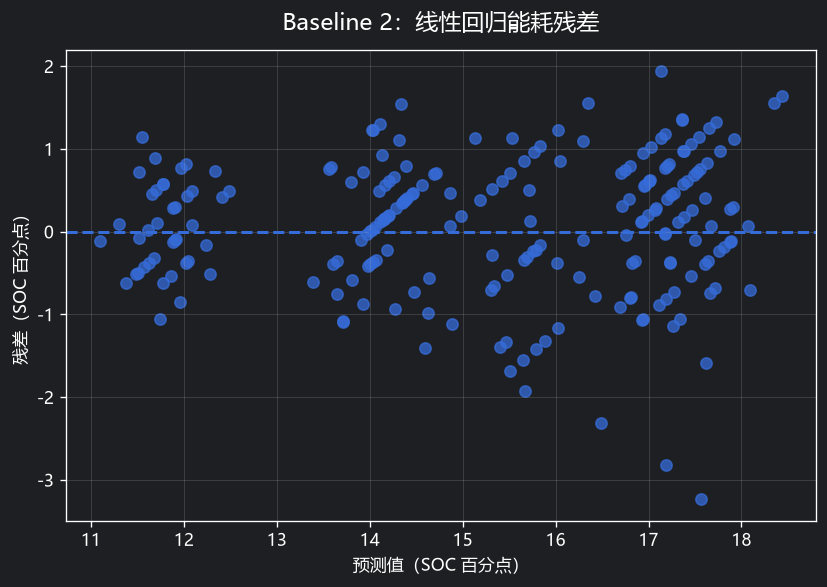

In [79]:
plot_actual_vs_predicted(
    y_energy_test,
    linear_energy_pred,
    "Baseline 2：线性回归能耗预测",
    "SOC 百分点",
)

plot_residuals(
    y_energy_test,
    linear_energy_pred,
    "Baseline 2：线性回归能耗残差",
    "SOC 百分点",
)

# XGBoost 回归

XGBoost 使用与线性回归完全相同的输入特征和数据划分。

In [80]:
def build_xgboost_model():
    return XGBRegressor(
        objective="reg:squarederror",
        n_estimators=80,
        max_depth=2,
        learning_rate=0.05,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_lambda=3.0,
        reg_alpha=0.1,
        min_child_weight=2,
        random_state=RANDOM_STATE,
        n_jobs=1,
    )


# 任务时间 XGBoost
xgb_time_model = build_xgboost_model()
xgb_time_model.fit(X_train, y_time_train)
xgb_time_pred = xgb_time_model.predict(X_test)

xgb_time_metrics = get_metrics(
    y_time_test,
    xgb_time_pred,
)

# 能耗 XGBoost
xgb_energy_model = build_xgboost_model()
xgb_energy_model.fit(X_train, y_energy_train)
xgb_energy_pred = xgb_energy_model.predict(X_test)

xgb_energy_metrics = get_metrics(
    y_energy_test,
    xgb_energy_pred,
)

print("任务时间 XGBoost：")
display(pd.DataFrame(
    [xgb_time_metrics],
    index=["XGBoost"],
).round(4))

print("能耗 XGBoost：")
display(pd.DataFrame(
    [xgb_energy_metrics],
    index=["XGBoost"],
).round(4))

任务时间 XGBoost：


,MAE,RMSE,R2
XGBoost,43.8863,56.0807,0.9146


能耗 XGBoost：


,MAE,RMSE,R2
XGBoost,0.6267,0.8143,0.859


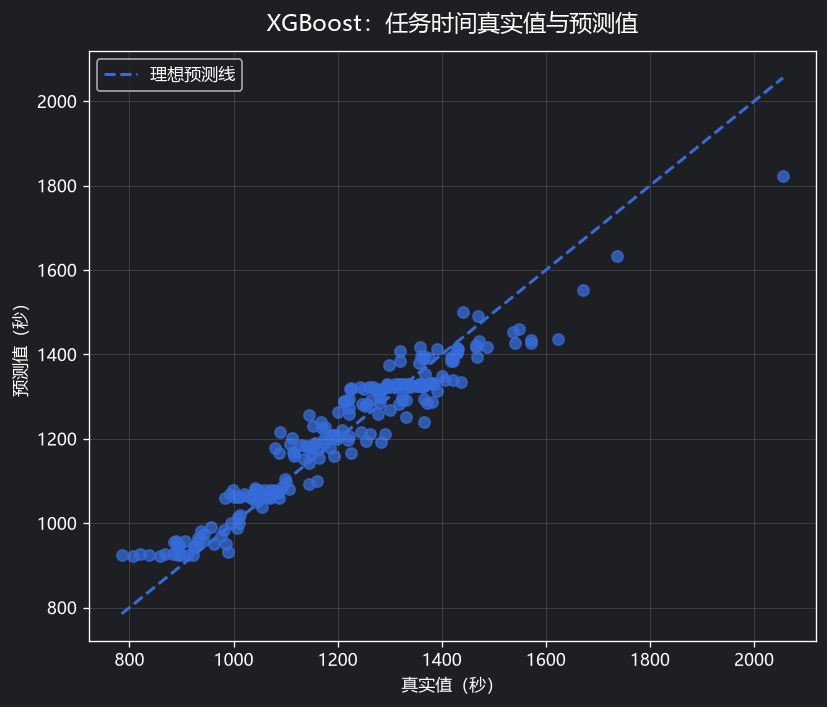

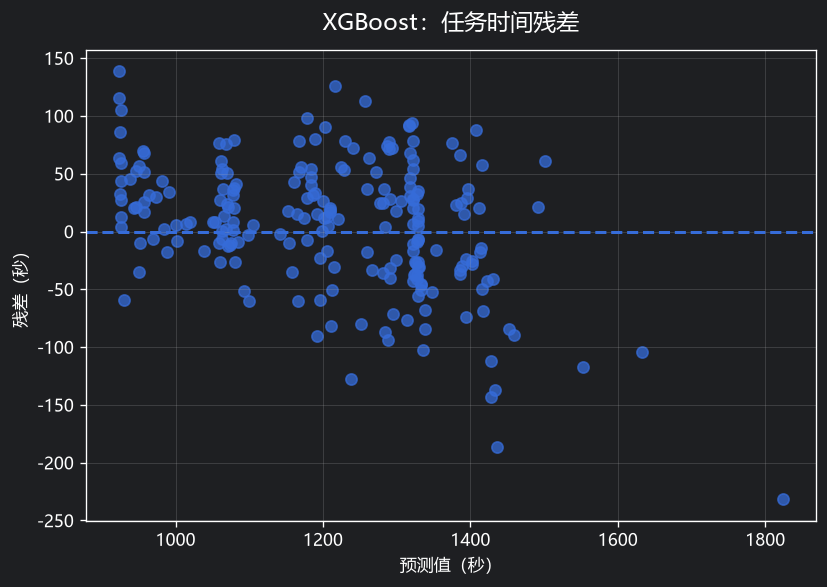

In [81]:
plot_actual_vs_predicted(
    y_time_test,
    xgb_time_pred,
    "XGBoost：任务时间真实值与预测值",
    "秒",
)

plot_residuals(
    y_time_test,
    xgb_time_pred,
    "XGBoost：任务时间残差",
    "秒",
)

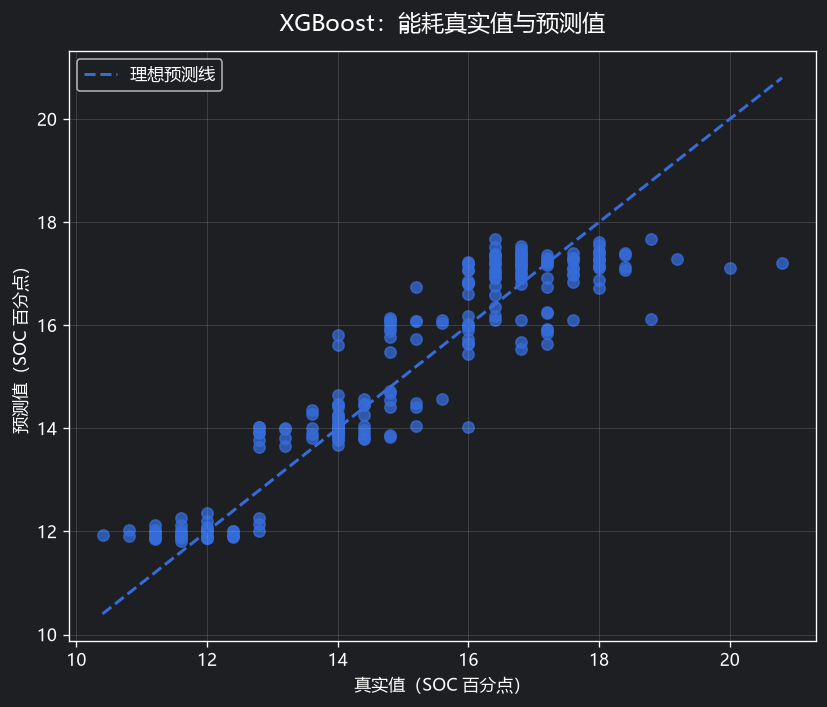

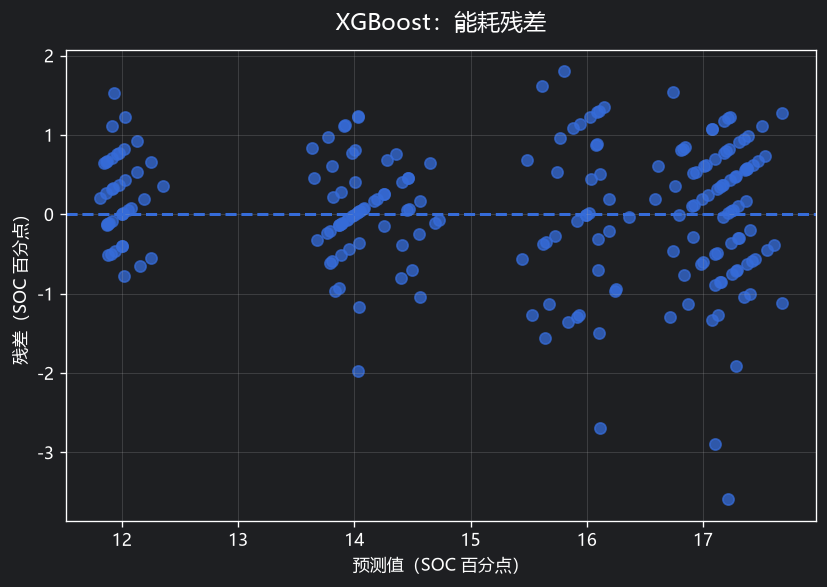

In [82]:
plot_actual_vs_predicted(
    y_energy_test,
    xgb_energy_pred,
    "XGBoost：能耗真实值与预测值",
    "SOC 百分点",
)

plot_residuals(
    y_energy_test,
    xgb_energy_pred,
    "XGBoost：能耗残差",
    "SOC 百分点",
)

## XGBoost 特征重要性

特征重要性分别针对任务时间模型和能耗模型绘制。

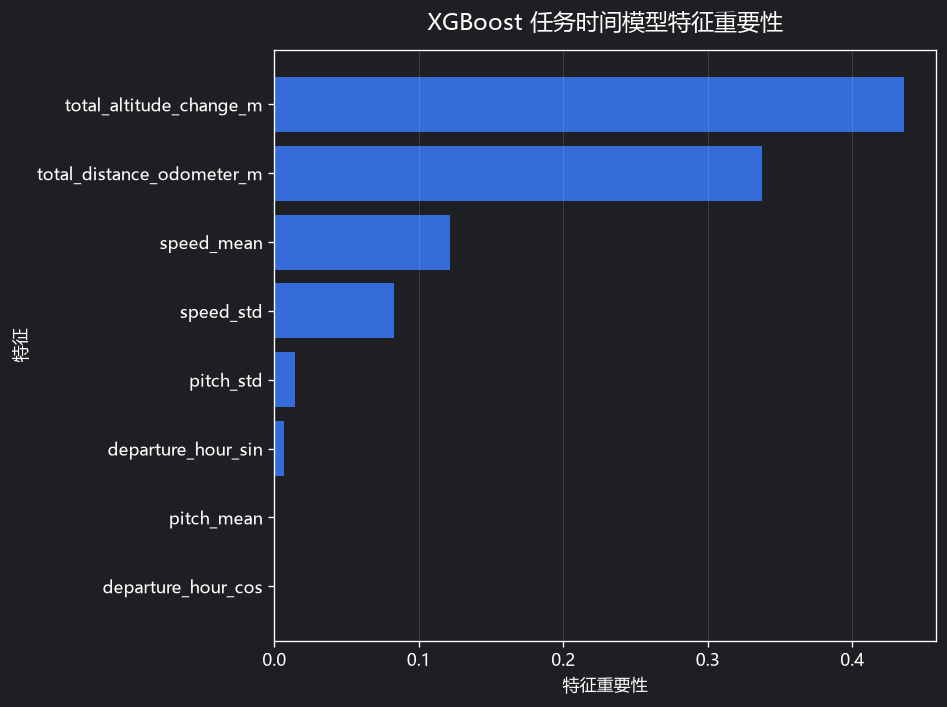

,feature,importance
3,total_altitude_change_m,0.4362
2,total_distance_odometer_m,0.3377
6,speed_mean,0.1219
7,speed_std,0.0826
5,pitch_std,0.0147
0,departure_hour_sin,0.0070
1,departure_hour_cos,0.0000
4,pitch_mean,0.0000


In [83]:
time_importance = pd.DataFrame({
    "feature": FEATURE_COLS,
    "importance": xgb_time_model.feature_importances_,
}).sort_values("importance")

plt.figure(figsize=(8, 6))
plt.barh(
    time_importance["feature"],
    time_importance["importance"],
)
plt.xlabel("特征重要性")
plt.ylabel("特征")
plt.title("XGBoost 任务时间模型特征重要性", fontsize=14, pad=12)
plt.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

display(
    time_importance
    .sort_values("importance", ascending=False)
    .round(4)
)

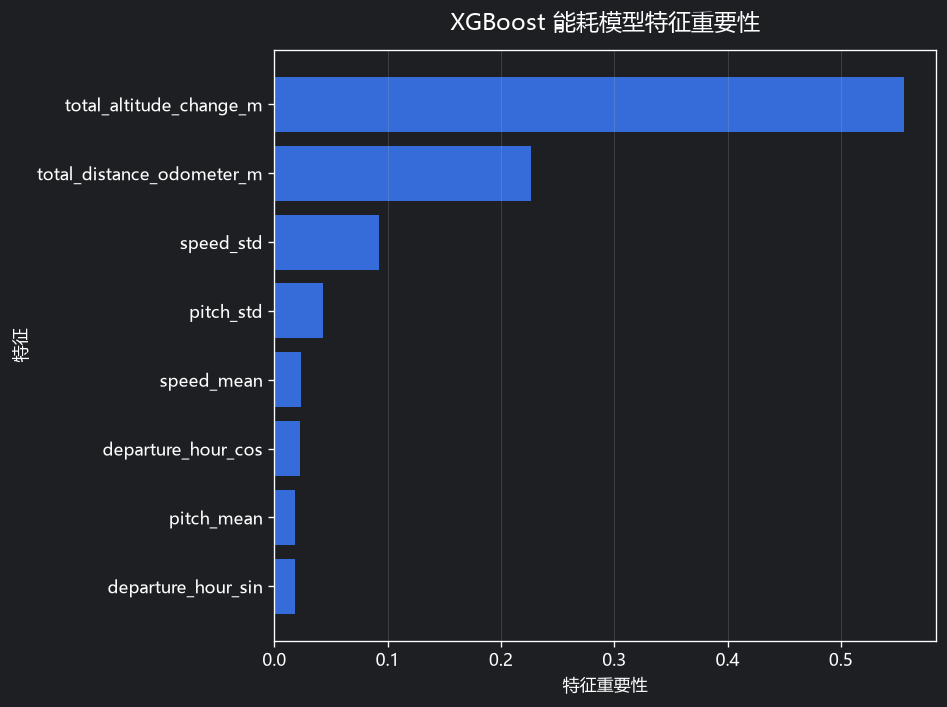

,feature,importance
3,total_altitude_change_m,0.5562
2,total_distance_odometer_m,0.2262
7,speed_std,0.0924
5,pitch_std,0.0429
6,speed_mean,0.0234
1,departure_hour_cos,0.0225
4,pitch_mean,0.0186
0,departure_hour_sin,0.0179


In [84]:
energy_importance = pd.DataFrame({
    "feature": FEATURE_COLS,
    "importance": xgb_energy_model.feature_importances_,
}).sort_values("importance")

plt.figure(figsize=(8, 6))
plt.barh(
    energy_importance["feature"],
    energy_importance["importance"],
)
plt.xlabel("特征重要性")
plt.ylabel("特征")
plt.title("XGBoost 能耗模型特征重要性", fontsize=14, pad=12)
plt.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

display(
    energy_importance
    .sort_values("importance", ascending=False)
    .round(4)
)

# XGBoost 网格搜索

网格搜索会完整遍历给定参数组合，并通过训练集交叉验证选择最优组合。

本 Notebook 搜索以下参数：

- `n_estimators`：树的数量；
- `max_depth`：树的最大深度；
- `learning_rate`：学习率；
- `subsample`：每棵树使用的训练样本比例；
- `colsample_bytree`：每棵树使用的特征比例。

为控制运行量，正则化参数保持为默认 XGBoost 模型中的设置：

- `min_child_weight = 2`
- `reg_alpha = 0.1`
- `reg_lambda = 3.0`

任务时间和能耗分别进行网格搜索。

In [85]:
# 参数网格
xgb_param_grid = {
    "n_estimators": [80, 120, 160, 200, 240],
    "max_depth": [2, 3, 4, 5],
    "learning_rate": [0.01, 0.03, 0.05, 0.10],
    "subsample": [0.80, 0.90, 1.00],
    "colsample_bytree": [0.80, 0.90, 1.00],
}

# 计算参数组合数量
grid_size = 1
for values in xgb_param_grid.values():
    grid_size = grid_size * len(values)

search_cv_folds = min(
    GRID_SEARCH_CV_FOLDS,
    len(X_train) // 2,
)

if search_cv_folds < 2:
    raise ValueError("训练样本太少，无法进行网格搜索。")

search_cv = KFold(
    n_splits=search_cv_folds,
    shuffle=True,
    random_state=RANDOM_STATE,
)

print(f"参数组合数：{grid_size}")
print(f"每个预测目标需要拟合：{grid_size * search_cv_folds} 次")
print(f"实际使用 {search_cv_folds} 折交叉验证。")

参数组合数：720
每个预测目标需要拟合：3600 次
实际使用 5 折交叉验证。


## 任务时间 XGBoost 网格搜索

评价指标使用训练集交叉验证 RMSE。RMSE 越小，参数组合越好。

In [86]:
time_grid_model = XGBRegressor(
    objective="reg:squarederror",
    min_child_weight=2,
    reg_alpha=0.1,
    reg_lambda=3.0,
    random_state=RANDOM_STATE,
    n_jobs=1,
)

time_grid_search = GridSearchCV(
    estimator=time_grid_model,
    param_grid=xgb_param_grid,
    scoring="neg_root_mean_squared_error",
    cv=search_cv,
    n_jobs=1,
    verbose=1,
    return_train_score=True,
)

time_grid_search.fit(X_train, y_time_train)

print("任务时间最优参数：")
display(pd.DataFrame(
    list(time_grid_search.best_params_.items()),
    columns=["parameter", "best_value"],
))

print(
    "任务时间最优训练集 CV RMSE："
    f"{-time_grid_search.best_score_:.4f} 秒"
)

Fitting 5 folds for each of 720 candidates, totalling 3600 fits
任务时间最优参数：


,parameter,best_value
0,colsample_bytree,1.0
1,learning_rate,0.1
2,max_depth,4.0
3,n_estimators,240.0
4,subsample,0.8


任务时间最优训练集 CV RMSE：39.0713 秒


,组合,CV_RMSE,std_test_score,params
702,组合 1,39.0713,7.9009,"{'colsample_bytree': 1.0, 'learning_rate': 0.1..."
699,组合 2,39.1738,8.0614,"{'colsample_bytree': 1.0, 'learning_rate': 0.1..."
696,组合 3,39.4372,8.0994,"{'colsample_bytree': 1.0, 'learning_rate': 0.1..."
693,组合 4,39.7668,8.0445,"{'colsample_bytree': 1.0, 'learning_rate': 0.1..."
687,组合 5,39.7698,8.0266,"{'colsample_bytree': 1.0, 'learning_rate': 0.1..."
417,组合 6,39.7922,8.9174,"{'colsample_bytree': 0.9, 'learning_rate': 0.0..."
711,组合 7,39.9749,9.6171,"{'colsample_bytree': 1.0, 'learning_rate': 0.1..."
684,组合 8,40.0498,8.1001,"{'colsample_bytree': 1.0, 'learning_rate': 0.1..."
717,组合 9,40.0500,9.5341,"{'colsample_bytree': 1.0, 'learning_rate': 0.1..."
714,组合 10,40.0602,9.5574,"{'colsample_bytree': 1.0, 'learning_rate': 0.1..."


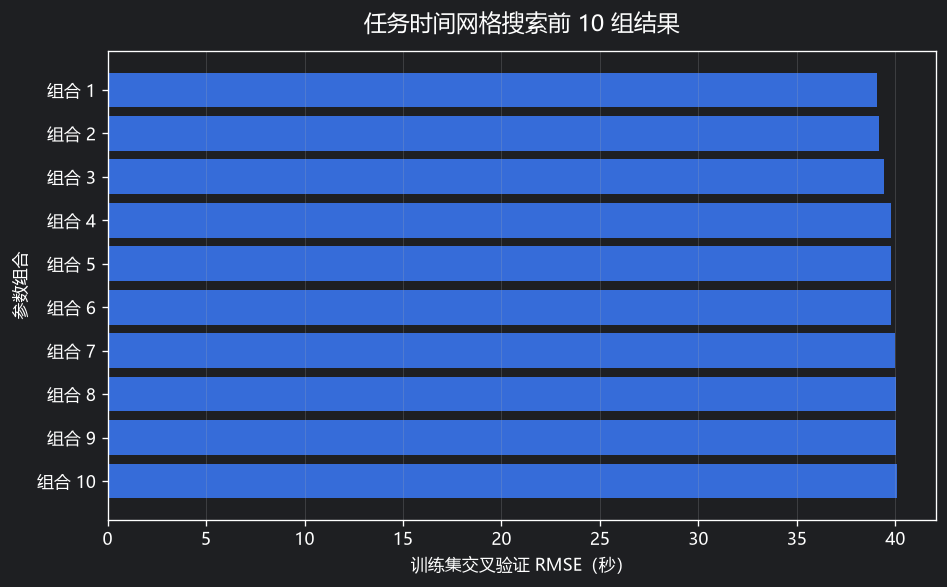

In [87]:
time_grid_results = pd.DataFrame(
    time_grid_search.cv_results_
)

time_grid_results["CV_RMSE"] = (
    -time_grid_results["mean_test_score"]
)

time_grid_top10 = (
    time_grid_results
    .sort_values("rank_test_score")
    .head(10)
    .copy()
)

time_grid_top10["组合"] = [
    f"组合 {i}" for i in range(1, len(time_grid_top10) + 1)
]

display(
    time_grid_top10[
        ["组合", "CV_RMSE", "std_test_score", "params"]
    ].round(4)
)

plt.figure(figsize=(8, 5))
plt.barh(
    time_grid_top10["组合"][::-1],
    time_grid_top10["CV_RMSE"][::-1],
)
plt.xlabel("训练集交叉验证 RMSE（秒）")
plt.ylabel("参数组合")
plt.title("任务时间网格搜索前 10 组结果", fontsize=14, pad=12)
plt.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

## 能耗 XGBoost 网格搜索

能耗模型独立搜索参数，不直接复用任务时间模型的最优参数。

In [88]:
energy_grid_model = XGBRegressor(
    objective="reg:squarederror",
    min_child_weight=2,
    reg_alpha=0.1,
    reg_lambda=3.0,
    random_state=RANDOM_STATE,
    n_jobs=1,
)

energy_grid_search = GridSearchCV(
    estimator=energy_grid_model,
    param_grid=xgb_param_grid,
    scoring="neg_root_mean_squared_error",
    cv=search_cv,
    n_jobs=1,
    verbose=1,
    return_train_score=True,
)

energy_grid_search.fit(X_train, y_energy_train)

print("能耗最优参数：")
display(pd.DataFrame(
    list(energy_grid_search.best_params_.items()),
    columns=["parameter", "best_value"],
))

print(
    "能耗最优训练集 CV RMSE："
    f"{-energy_grid_search.best_score_:.4f} SOC 百分点"
)

Fitting 5 folds for each of 720 candidates, totalling 3600 fits
能耗最优参数：


,parameter,best_value
0,colsample_bytree,0.80
1,learning_rate,0.03
2,max_depth,3.00
3,n_estimators,240.00
4,subsample,0.80


能耗最优训练集 CV RMSE：0.7122 SOC 百分点


,组合,CV_RMSE,std_test_score,params
87,组合 1,0.7122,0.0480,"{'colsample_bytree': 0.8, 'learning_rate': 0.0..."
372,组合 2,0.7125,0.0531,"{'colsample_bytree': 0.9, 'learning_rate': 0.0..."
141,组合 3,0.7127,0.0514,"{'colsample_bytree': 0.8, 'learning_rate': 0.0..."
369,组合 4,0.7130,0.0502,"{'colsample_bytree': 0.9, 'learning_rate': 0.0..."
129,组合 5,0.7130,0.0485,"{'colsample_bytree': 0.8, 'learning_rate': 0.0..."
88,组合 6,0.7135,0.0529,"{'colsample_bytree': 0.8, 'learning_rate': 0.0..."
84,组合 7,0.7138,0.0465,"{'colsample_bytree': 0.8, 'learning_rate': 0.0..."
396,组合 8,0.7140,0.0471,"{'colsample_bytree': 0.9, 'learning_rate': 0.0..."
102,组合 9,0.7143,0.0513,"{'colsample_bytree': 0.8, 'learning_rate': 0.0..."
144,组合 10,0.7143,0.0531,"{'colsample_bytree': 0.8, 'learning_rate': 0.0..."


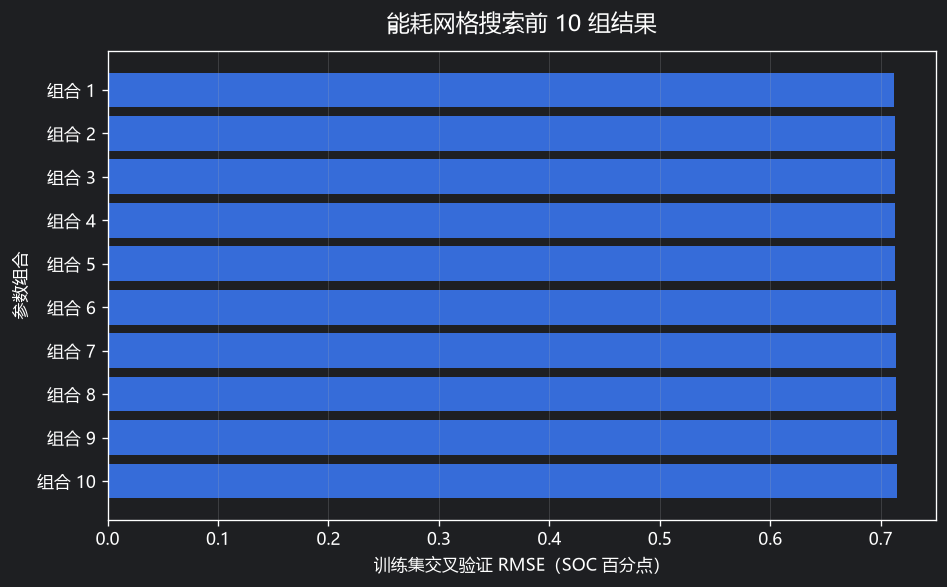

In [89]:
energy_grid_results = pd.DataFrame(
    energy_grid_search.cv_results_
)

energy_grid_results["CV_RMSE"] = (
    -energy_grid_results["mean_test_score"]
)

energy_grid_top10 = (
    energy_grid_results
    .sort_values("rank_test_score")
    .head(10)
    .copy()
)

energy_grid_top10["组合"] = [
    f"组合 {i}" for i in range(1, len(energy_grid_top10) + 1)
]

display(
    energy_grid_top10[
        ["组合", "CV_RMSE", "std_test_score", "params"]
    ].round(4)
)

plt.figure(figsize=(8, 5))
plt.barh(
    energy_grid_top10["组合"][::-1],
    energy_grid_top10["CV_RMSE"][::-1],
)
plt.xlabel("训练集交叉验证 RMSE（SOC 百分点）")
plt.ylabel("参数组合")
plt.title("能耗网格搜索前 10 组结果", fontsize=14, pad=12)
plt.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

## 使用最优参数预测测试集

`best_estimator_` 已经使用完整训练集重新拟合，因此可以直接用于测试集预测。

In [90]:
tuned_xgb_time_model = time_grid_search.best_estimator_
tuned_xgb_energy_model = energy_grid_search.best_estimator_

tuned_xgb_time_pred = tuned_xgb_time_model.predict(X_test)
tuned_xgb_energy_pred = tuned_xgb_energy_model.predict(X_test)

tuned_xgb_time_metrics = get_metrics(
    y_time_test,
    tuned_xgb_time_pred,
)

tuned_xgb_energy_metrics = get_metrics(
    y_energy_test,
    tuned_xgb_energy_pred,
)

print("网格搜索后的任务时间 XGBoost：")
display(pd.DataFrame(
    [tuned_xgb_time_metrics],
    index=["网格搜索 XGBoost"],
).round(4))

print("网格搜索后的能耗 XGBoost：")
display(pd.DataFrame(
    [tuned_xgb_energy_metrics],
    index=["网格搜索 XGBoost"],
).round(4))

网格搜索后的任务时间 XGBoost：


,MAE,RMSE,R2
网格搜索 XGBoost,25.7952,36.0052,0.9648


网格搜索后的能耗 XGBoost：


,MAE,RMSE,R2
网格搜索 XGBoost,0.62,0.8024,0.8631


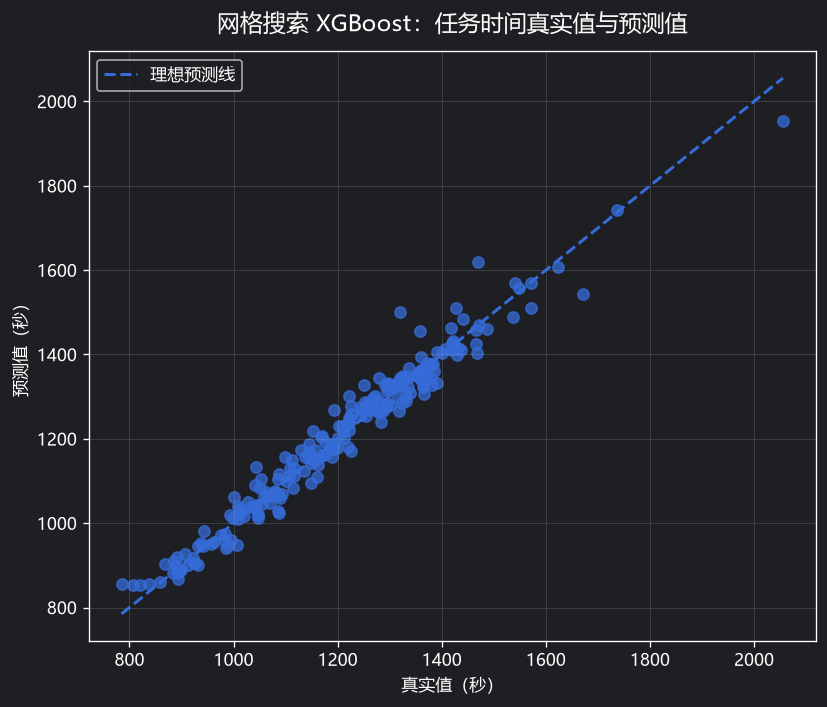

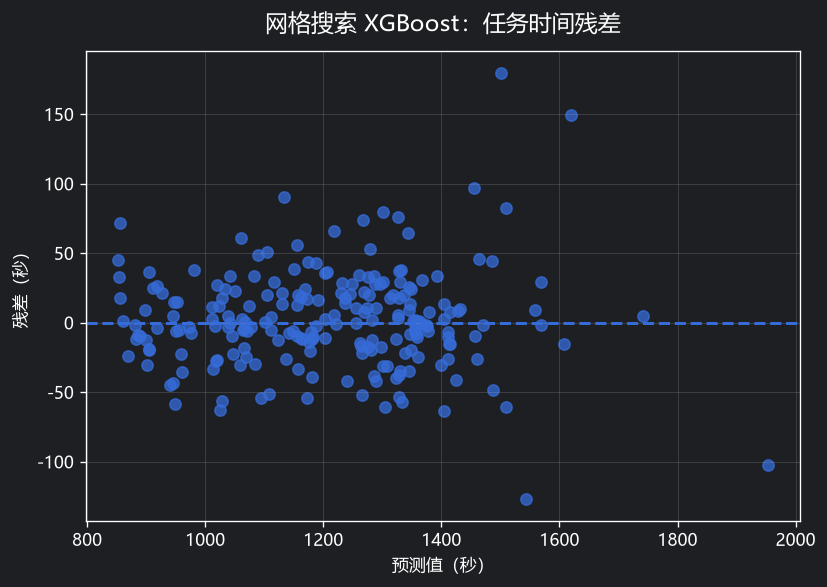

In [91]:
plot_actual_vs_predicted(
    y_time_test,
    tuned_xgb_time_pred,
    "网格搜索 XGBoost：任务时间真实值与预测值",
    "秒",
)

plot_residuals(
    y_time_test,
    tuned_xgb_time_pred,
    "网格搜索 XGBoost：任务时间残差",
    "秒",
)

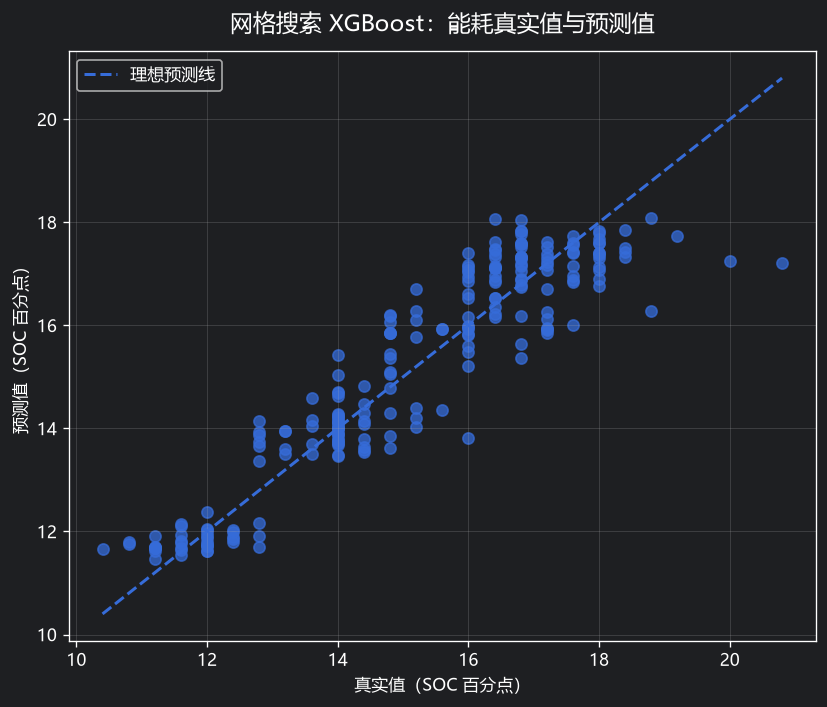

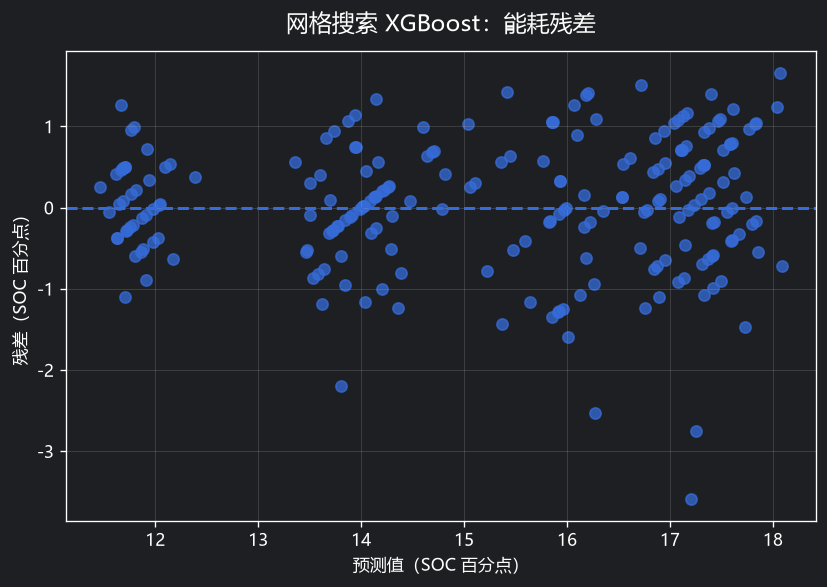

In [92]:
plot_actual_vs_predicted(
    y_energy_test,
    tuned_xgb_energy_pred,
    "网格搜索 XGBoost：能耗真实值与预测值",
    "SOC 百分点",
)

plot_residuals(
    y_energy_test,
    tuned_xgb_energy_pred,
    "网格搜索 XGBoost：能耗残差",
    "SOC 百分点",
)

# 模型统一比较

任务时间比较：

- 里程比例 Baseline；
- 线性回归；
- 默认参数 XGBoost；
- 网格搜索后的 XGBoost。

能耗比较：

- 里程比例 Baseline；
- 线性回归；
- 默认参数 XGBoost；
- 网格搜索后的 XGBoost。

In [93]:
time_comparison = pd.DataFrame([
    {
        "model": "里程比例 Baseline",
        **baseline1_time_metrics,
    },
    {
        "model": "线性回归",
        **linear_time_metrics,
    },
    {
        "model": "默认 XGBoost",
        **xgb_time_metrics,
    },
    {
        "model": "网格搜索 XGBoost",
        **tuned_xgb_time_metrics,
    },
]).set_index("model")

energy_comparison = pd.DataFrame([
    {
        "model": "里程比例 Baseline",
        **baseline1_energy_metrics,
    },
    {
        "model": "线性回归",
        **linear_energy_metrics,
    },
    {
        "model": "默认 XGBoost",
        **xgb_energy_metrics,
    },
    {
        "model": "网格搜索 XGBoost",
        **tuned_xgb_energy_metrics,
    },
]).set_index("model")

print("任务时间测试集比较：")
display(time_comparison.round(4))

print("能耗测试集比较：")
display(energy_comparison.round(4))

任务时间测试集比较：


,MAE,RMSE,R2
model,,,
里程比例 Baseline,103.2798,139.1167,0.4747
线性回归,31.2902,38.9808,0.9588
默认 XGBoost,43.8863,56.0807,0.9146
网格搜索 XGBoost,25.7952,36.0052,0.9648


能耗测试集比较：


,MAE,RMSE,R2
model,,,
里程比例 Baseline,1.3469,1.7132,0.3759
线性回归,0.6546,0.8172,0.8580
默认 XGBoost,0.6267,0.8143,0.8590
网格搜索 XGBoost,0.6200,0.8024,0.8631


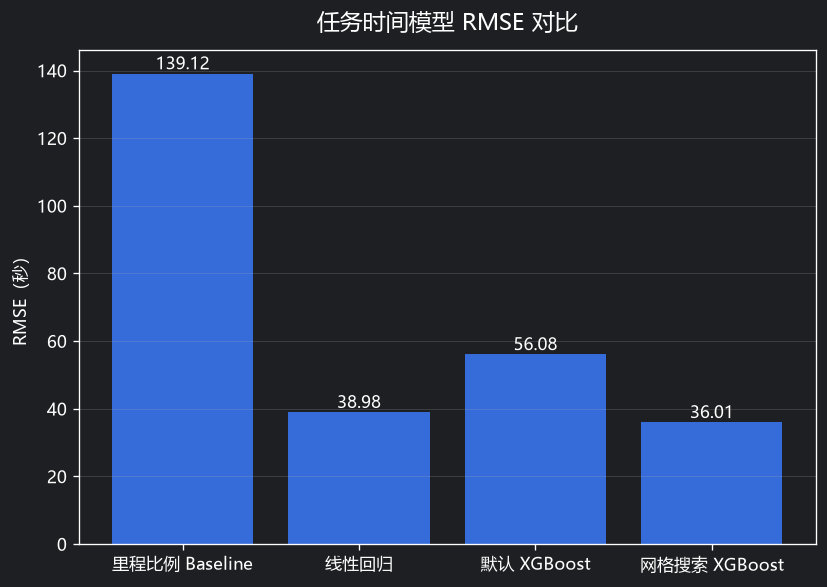

In [94]:
plt.figure(figsize=(7, 5))
bars = plt.bar(
    time_comparison.index,
    time_comparison["RMSE"],
)
plt.ylabel("RMSE（秒）")
plt.title("任务时间模型 RMSE 对比", fontsize=14, pad=12)
plt.grid(axis="y", alpha=0.25)

for bar, value in zip(bars, time_comparison["RMSE"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.2f}",
        ha="center",
        va="bottom",
    )

plt.tight_layout()
plt.show()

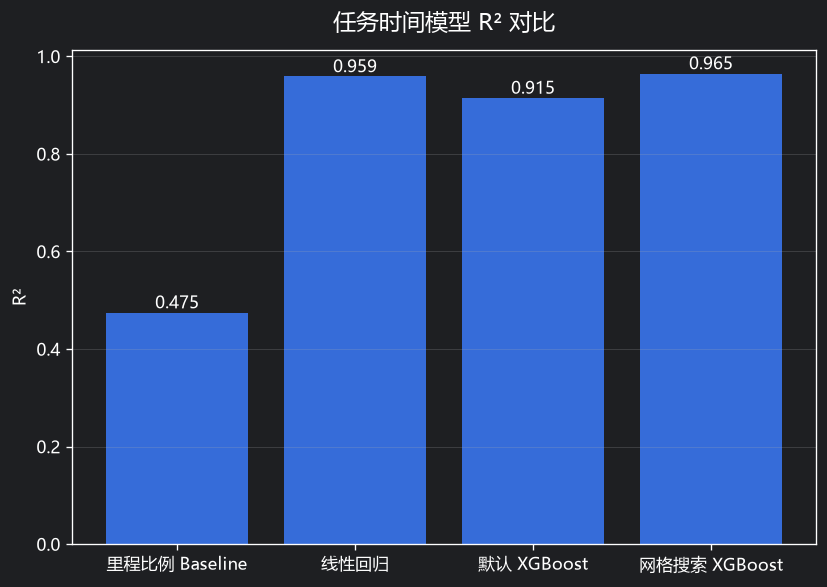

In [95]:
plt.figure(figsize=(7, 5))
bars = plt.bar(
    time_comparison.index,
    time_comparison["R2"],
)
plt.ylabel("R²")
plt.title("任务时间模型 R² 对比", fontsize=14, pad=12)
plt.grid(axis="y", alpha=0.25)

for bar, value in zip(bars, time_comparison["R2"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.3f}",
        ha="center",
        va="bottom",
    )

plt.tight_layout()
plt.show()

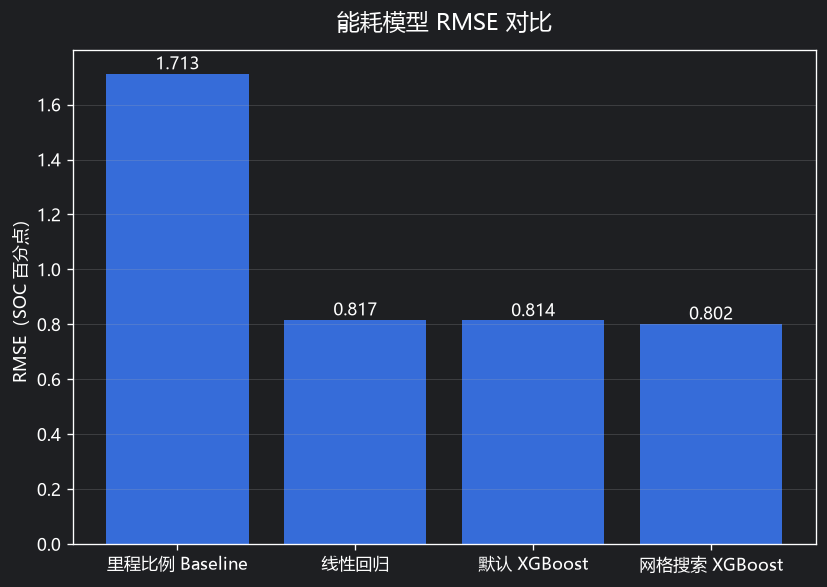

In [96]:
plt.figure(figsize=(7, 5))
bars = plt.bar(
    energy_comparison.index,
    energy_comparison["RMSE"],
)
plt.ylabel("RMSE（SOC 百分点）")
plt.title("能耗模型 RMSE 对比", fontsize=14, pad=12)
plt.grid(axis="y", alpha=0.25)

for bar, value in zip(bars, energy_comparison["RMSE"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.3f}",
        ha="center",
        va="bottom",
    )

plt.tight_layout()
plt.show()

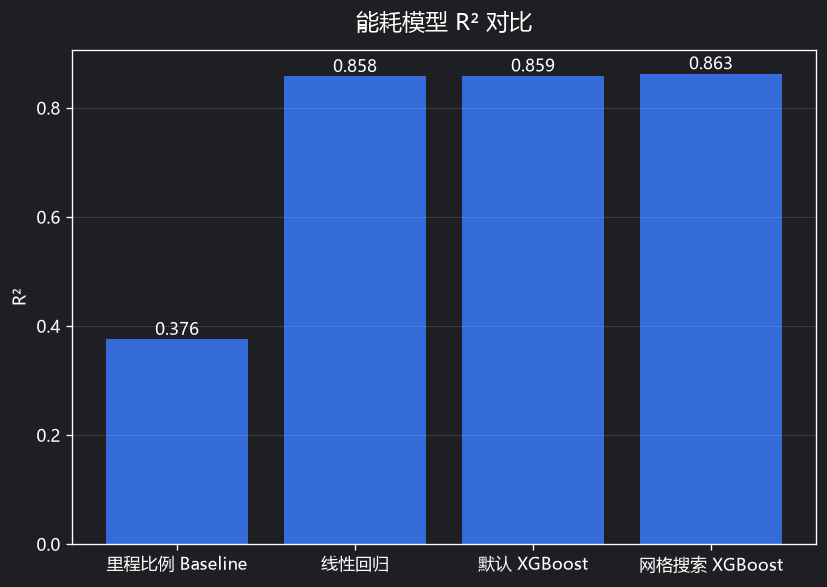

In [97]:
plt.figure(figsize=(7, 5))
bars = plt.bar(
    energy_comparison.index,
    energy_comparison["R2"],
)
plt.ylabel("R²")
plt.title("能耗模型 R² 对比", fontsize=14, pad=12)
plt.grid(axis="y", alpha=0.25)

for bar, value in zip(bars, energy_comparison["R2"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.3f}",
        ha="center",
        va="bottom",
    )

plt.tight_layout()
plt.show()

# 可选：5 折交叉验证

测试集结果容易受一次随机划分影响，因此这里再用 5 折交叉验证比较模型稳定性。

每一折都会重新拟合模型，比例 Baseline 的系数也只用该折训练数据计算。

In [98]:
n_splits = min(5, len(df) // 2)

if n_splits < 2:
    raise ValueError("样本数太少，无法进行交叉验证。")

cv = KFold(
    n_splits=n_splits,
    shuffle=True,
    random_state=RANDOM_STATE,
)

scoring = {
    "MAE": "neg_mean_absolute_error",
    "RMSE": "neg_root_mean_squared_error",
    "R2": "r2",
}

print(f"使用 {n_splits} 折交叉验证。")

使用 5 折交叉验证。


In [99]:
# 里程比例 Baseline 的时间和能耗交叉验证
baseline1_cv_rows = []

for fold, (train_idx, valid_idx) in enumerate(
    cv.split(df),
    start=1,
):
    fold_train = df.iloc[train_idx]
    fold_valid = df.iloc[valid_idx]

    d_train = (
        fold_train["total_distance_odometer_m"]
        .to_numpy()
    )

    t_train = fold_train[TIME_TARGET].to_numpy()
    e_train = fold_train[ENERGY_TARGET].to_numpy()

    fold_time_k = (
        np.sum(d_train * t_train)
        / np.sum(d_train ** 2)
    )

    fold_energy_k = (
        np.sum(d_train * e_train)
        / np.sum(d_train ** 2)
    )

    fold_time_pred = (
        fold_time_k
        * fold_valid["total_distance_odometer_m"]
        .to_numpy()
    )

    fold_energy_pred = (
        fold_energy_k
        * fold_valid["total_distance_odometer_m"]
        .to_numpy()
    )

    fold_time_metrics = get_metrics(
        fold_valid[TIME_TARGET],
        fold_time_pred,
    )

    fold_energy_metrics = get_metrics(
        fold_valid[ENERGY_TARGET],
        fold_energy_pred,
    )

    baseline1_cv_rows.append({
        "fold": fold,
        "time_k_s_per_m": fold_time_k,
        "time_MAE": fold_time_metrics["MAE"],
        "time_RMSE": fold_time_metrics["RMSE"],
        "time_R2": fold_time_metrics["R2"],
        "energy_k_soc_pct_per_m": fold_energy_k,
        "energy_MAE": fold_energy_metrics["MAE"],
        "energy_RMSE": fold_energy_metrics["RMSE"],
        "energy_R2": fold_energy_metrics["R2"],
    })

baseline1_cv = pd.DataFrame(
    baseline1_cv_rows
)

display(baseline1_cv.round(4))

,fold,time_k_s_per_m,time_MAE,time_RMSE,time_R2,energy_k_soc_pct_per_m,energy_MAE,energy_RMSE,energy_R2
0,1,0.3007,103.2798,139.1167,0.4747,0.0038,1.3469,1.7132,0.3759
1,2,0.2993,102.1565,145.5426,0.3103,0.0038,1.3597,1.6926,0.2504
2,3,0.3011,101.7662,134.5780,0.5310,0.0038,1.4553,1.7894,0.3033
3,4,0.2988,111.5610,155.2237,0.4122,0.0038,1.5664,1.8359,0.2492
4,5,0.3000,91.7969,119.5424,0.5954,0.0038,1.4430,1.6995,0.3845


In [100]:
# 线性回归、默认 XGBoost 和网格搜索 XGBoost 的交叉验证
linear_time_cv = cross_validate(
    LinearRegression(),
    df[FEATURE_COLS],
    df[TIME_TARGET],
    cv=cv,
    scoring=scoring,
)

xgb_time_cv = cross_validate(
    build_xgboost_model(),
    df[FEATURE_COLS],
    df[TIME_TARGET],
    cv=cv,
    scoring=scoring,
)

tuned_xgb_time_cv = cross_validate(
    XGBRegressor(
        objective="reg:squarederror",
        min_child_weight=2,
        reg_alpha=0.1,
        reg_lambda=3.0,
        random_state=RANDOM_STATE,
        n_jobs=1,
        **time_grid_search.best_params_,
    ),
    df[FEATURE_COLS],
    df[TIME_TARGET],
    cv=cv,
    scoring=scoring,
)

linear_energy_cv = cross_validate(
    LinearRegression(),
    df[FEATURE_COLS],
    df[ENERGY_TARGET],
    cv=cv,
    scoring=scoring,
)

xgb_energy_cv = cross_validate(
    build_xgboost_model(),
    df[FEATURE_COLS],
    df[ENERGY_TARGET],
    cv=cv,
    scoring=scoring,
)

tuned_xgb_energy_cv = cross_validate(
    XGBRegressor(
        objective="reg:squarederror",
        min_child_weight=2,
        reg_alpha=0.1,
        reg_lambda=3.0,
        random_state=RANDOM_STATE,
        n_jobs=1,
        **energy_grid_search.best_params_,
    ),
    df[FEATURE_COLS],
    df[ENERGY_TARGET],
    cv=cv,
    scoring=scoring,
)

print("交叉验证完成。")
print(
    "说明：网格搜索模型的参数来自前面的训练集搜索，"
    "这里使用固定参数评价整体稳定性。"
)

交叉验证完成。
说明：网格搜索模型的参数来自前面的训练集搜索，这里使用固定参数评价整体稳定性。


In [101]:
time_cv_comparison = pd.DataFrame([
    {
        "model": "里程比例 Baseline",
        "CV_MAE": baseline1_cv["time_MAE"].mean(),
        "CV_RMSE": baseline1_cv["time_RMSE"].mean(),
        "CV_R2": baseline1_cv["time_R2"].mean(),
    },
    {
        "model": "线性回归",
        "CV_MAE": -linear_time_cv["test_MAE"].mean(),
        "CV_RMSE": -linear_time_cv["test_RMSE"].mean(),
        "CV_R2": linear_time_cv["test_R2"].mean(),
    },
    {
        "model": "默认 XGBoost",
        "CV_MAE": -xgb_time_cv["test_MAE"].mean(),
        "CV_RMSE": -xgb_time_cv["test_RMSE"].mean(),
        "CV_R2": xgb_time_cv["test_R2"].mean(),
    },
    {
        "model": "网格搜索 XGBoost",
        "CV_MAE": -tuned_xgb_time_cv["test_MAE"].mean(),
        "CV_RMSE": -tuned_xgb_time_cv["test_RMSE"].mean(),
        "CV_R2": tuned_xgb_time_cv["test_R2"].mean(),
    },
]).set_index("model")

energy_cv_comparison = pd.DataFrame([
    {
        "model": "里程比例 Baseline",
        "CV_MAE": baseline1_cv["energy_MAE"].mean(),
        "CV_RMSE": baseline1_cv["energy_RMSE"].mean(),
        "CV_R2": baseline1_cv["energy_R2"].mean(),
    },
    {
        "model": "线性回归",
        "CV_MAE": -linear_energy_cv["test_MAE"].mean(),
        "CV_RMSE": -linear_energy_cv["test_RMSE"].mean(),
        "CV_R2": linear_energy_cv["test_R2"].mean(),
    },
    {
        "model": "默认 XGBoost",
        "CV_MAE": -xgb_energy_cv["test_MAE"].mean(),
        "CV_RMSE": -xgb_energy_cv["test_RMSE"].mean(),
        "CV_R2": xgb_energy_cv["test_R2"].mean(),
    },
    {
        "model": "网格搜索 XGBoost",
        "CV_MAE": -tuned_xgb_energy_cv["test_MAE"].mean(),
        "CV_RMSE": -tuned_xgb_energy_cv["test_RMSE"].mean(),
        "CV_R2": tuned_xgb_energy_cv["test_R2"].mean(),
    },
]).set_index("model")

print("任务时间交叉验证平均结果：")
display(time_cv_comparison.round(4))

print("能耗交叉验证平均结果：")
display(energy_cv_comparison.round(4))

任务时间交叉验证平均结果：


,CV_MAE,CV_RMSE,CV_R2
model,,,
里程比例 Baseline,102.1121,138.8007,0.4647
线性回归,32.9805,43.3248,0.9476
默认 XGBoost,46.6111,65.7418,0.8795
网格搜索 XGBoost,26.1805,37.0738,0.9616


能耗交叉验证平均结果：


,CV_MAE,CV_RMSE,CV_R2
model,,,
里程比例 Baseline,1.4343,1.7461,0.3127
线性回归,0.5815,0.7365,0.8776
默认 XGBoost,0.5962,0.7619,0.8688
网格搜索 XGBoost,0.5786,0.7336,0.8783


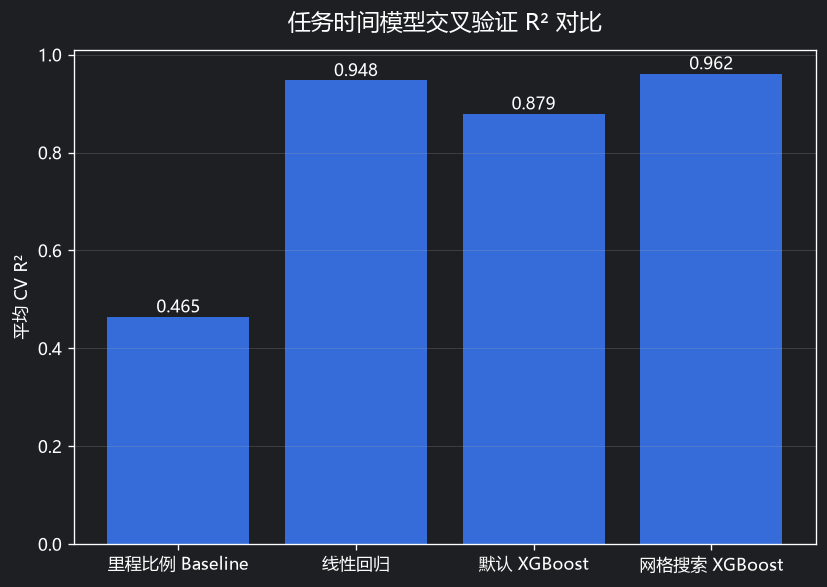

In [102]:
plt.figure(figsize=(7, 5))
bars = plt.bar(
    time_cv_comparison.index,
    time_cv_comparison["CV_R2"],
)
plt.ylabel("平均 CV R²")
plt.title("任务时间模型交叉验证 R² 对比", fontsize=14, pad=12)
plt.grid(axis="y", alpha=0.25)

for bar, value in zip(bars, time_cv_comparison["CV_R2"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.3f}",
        ha="center",
        va="bottom",
    )

plt.tight_layout()
plt.show()

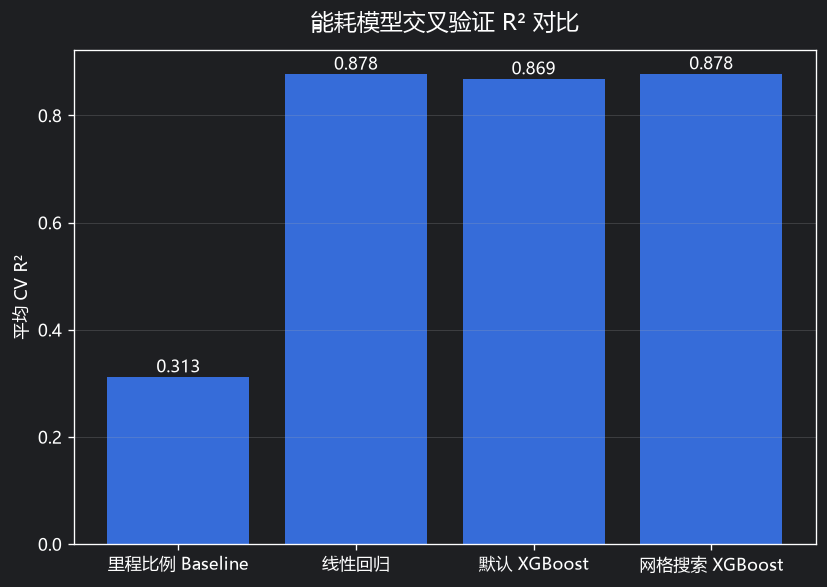

In [103]:
plt.figure(figsize=(7, 5))
bars = plt.bar(
    energy_cv_comparison.index,
    energy_cv_comparison["CV_R2"],
)
plt.ylabel("平均 CV R²")
plt.title("能耗模型交叉验证 R² 对比", fontsize=14, pad=12)
plt.grid(axis="y", alpha=0.25)

for bar, value in zip(bars, energy_cv_comparison["CV_R2"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.3f}",
        ha="center",
        va="bottom",
    )

plt.tight_layout()
plt.show()

# 保存模型与预测结果

保存内容包括：

- 里程比例 Baseline 系数 JSON；
- 两个线性回归模型；
- 两个 XGBoost 模型；
- 测试集逐条预测结果；
- 测试集和交叉验证指标。

In [104]:
# 保存模型
joblib.dump(
    linear_time_model,
    OUTPUT_DIR / "linear_time_model.joblib",
)
joblib.dump(
    linear_energy_model,
    OUTPUT_DIR / "linear_energy_model.joblib",
)
joblib.dump(
    xgb_time_model,
    OUTPUT_DIR / "xgboost_time_default_model.joblib",
)
joblib.dump(
    xgb_energy_model,
    OUTPUT_DIR / "xgboost_energy_default_model.joblib",
)
joblib.dump(
    tuned_xgb_time_model,
    OUTPUT_DIR / "xgboost_time_grid_search_model.joblib",
)
joblib.dump(
    tuned_xgb_energy_model,
    OUTPUT_DIR / "xgboost_energy_grid_search_model.joblib",
)

# 保存网格搜索最优参数
best_grid_parameters = {
    "time_best_params": time_grid_search.best_params_,
    "time_best_cv_rmse": -time_grid_search.best_score_,
    "energy_best_params": energy_grid_search.best_params_,
    "energy_best_cv_rmse": -energy_grid_search.best_score_,
}

with (
    OUTPUT_DIR / "xgboost_grid_search_best_parameters.json"
).open("w", encoding="utf-8") as f:
    json.dump(
        best_grid_parameters,
        f,
        ensure_ascii=False,
        indent=2,
    )

# 保存完整网格搜索结果
time_grid_results.to_csv(
    OUTPUT_DIR / "time_grid_search_results.csv",
    index=False,
    encoding="utf-8-sig",
)

energy_grid_results.to_csv(
    OUTPUT_DIR / "energy_grid_search_results.csv",
    index=False,
    encoding="utf-8-sig",
)

# 保存测试集逐条预测
prediction_result = test_df[
    [
        "task_id",
        "task_index",
        "source_file",
        "total_distance_odometer_m",
        TIME_TARGET,
        ENERGY_TARGET,
    ]
].copy()

prediction_result["baseline1_time_pred_s"] = baseline1_time_pred
prediction_result["baseline1_energy_pred_pct"] = baseline1_energy_pred
prediction_result["linear_time_pred_s"] = linear_time_pred
prediction_result["xgboost_time_default_pred_s"] = xgb_time_pred
prediction_result["xgboost_time_grid_pred_s"] = tuned_xgb_time_pred
prediction_result["linear_energy_pred_pct"] = linear_energy_pred
prediction_result["xgboost_energy_default_pred_pct"] = xgb_energy_pred
prediction_result["xgboost_energy_grid_pred_pct"] = tuned_xgb_energy_pred

prediction_result.to_csv(
    OUTPUT_DIR / "test_predictions.csv",
    index=False,
    encoding="utf-8-sig",
)

# 保存指标
time_comparison.to_csv(
    OUTPUT_DIR / "time_test_metrics.csv",
    encoding="utf-8-sig",
)
energy_comparison.to_csv(
    OUTPUT_DIR / "energy_test_metrics.csv",
    encoding="utf-8-sig",
)
time_cv_comparison.to_csv(
    OUTPUT_DIR / "time_cross_validation_metrics.csv",
    encoding="utf-8-sig",
)
energy_cv_comparison.to_csv(
    OUTPUT_DIR / "energy_cross_validation_metrics.csv",
    encoding="utf-8-sig",
)

print("全部结果已保存到：", OUTPUT_DIR)
display(prediction_result.head(10).round(4))

全部结果已保存到： ..\target\ModelResults


,task_id,task_index,source_file,total_distance_odometer_m,task_duration_s,total_energy_soc_delta_pct,baseline1_time_pred_s,baseline1_energy_pred_pct,linear_time_pred_s,xgboost_time_default_pred_s,xgboost_time_grid_pred_s,linear_energy_pred_pct,xgboost_energy_default_pred_pct,xgboost_energy_grid_pred_pct
0,8064241511481601,43,TLE00860VR1450018卸料任务_特征和标签.json,3500.0,1019.1463,13.2,1052.5871,13.2232,1017.5887,1069.961670,1016.518921,13.9239,13.806100,13.603300
1,8065135005860097,43,TLE00860ER1450011卸料任务_特征和标签.json,4875.0,1278.7740,16.8,1466.1034,18.4180,1354.2857,1305.253174,1289.545044,16.2476,16.097601,16.184799
2,8069905531109633,89,TLE00860CR1450020卸料任务_特征和标签.json,4250.0,1108.9244,14.4,1278.1415,16.0568,1122.4381,1188.630127,1129.972778,14.8684,14.454000,14.297500
3,8066679182082305,61,TLE00900JR1450046卸料任务_特征和标签.json,2625.0,820.8870,11.6,789.4403,9.9174,881.6161,926.116211,853.630920,11.5192,11.914800,11.811300
4,8067402709188865,68,TLE00900AR1450052卸料任务_特征和标签.json,4125.0,1323.0825,16.0,1240.5491,15.5845,1268.5787,1291.238403,1326.665039,16.7080,16.848600,16.853701
5,8064903191462145,47,TLE00900VR1450048卸料任务_特征和标签.json,4500.0,1364.6498,17.6,1353.3262,17.0013,1354.3019,1321.535645,1356.562256,17.2272,17.001200,17.143700
6,8067366011945217,70,TLE00860HR1450010卸料任务_特征和标签.json,3000.0,898.3948,11.2,902.2175,11.3342,886.0139,925.356018,888.870789,11.7044,11.862500,11.703500
7,8061142448472321,1,TLE00860VR1450018卸料任务_特征和标签.json,4125.0,1221.8573,17.2,1240.5491,15.5845,1272.0753,1293.750488,1301.667603,16.8219,16.738300,16.706100
8,8069981954031873,115,TLE00900VR1450048卸料任务_特征和标签.json,4125.0,1149.1676,15.2,1240.5491,15.5845,1084.5359,1164.404663,1095.308716,14.6365,14.494700,14.203900
9,8065218275868929,48,TLE00900AR1450052卸料任务_特征和标签.json,4125.0,1365.7869,16.8,1240.5491,15.5845,1274.2230,1294.424438,1328.038818,16.7590,17.039200,17.188801


# 结论阅读建议

建议按以下顺序解读：

1. 比较 Baseline、默认 XGBoost 和网格搜索 XGBoost 的测试集 RMSE；
2. 查看网格搜索的训练集交叉验证 RMSE；
3. 比较测试集和交叉验证结果是否一致；
4. 查看真实值—预测值图是否贴近对角线；
5. 查看残差是否围绕 0 随机分布；
6. 判断网格搜索带来的提升是否稳定。

注意：

- 测试集不能用于选择参数；
- 网格搜索只保证找到当前参数网格中的最优组合；
- 可以在第一轮最优参数附近设置更细的第二轮网格；
- 当前后续交叉验证使用已经搜索出的固定参数，不是严格的嵌套交叉验证；
- 如果目标是发车前预测，应检查全程 `speed_mean`、`speed_std` 等特征是否造成信息泄漏。